# BASIL Dataset — Exploratory Data Analysis

**Project:** NewsLens — computational analysis of media framing and bias
**Dataset:** BASIL (Bias Annotation Spans on the Informational Level)

This notebook explores the BASIL dataset that NewsLens is built on: its
structure, the articles it contains, and — most importantly — the **1,700+
human bias annotations** that make BASIL a *labeled* bias corpus rather than
just a collection of news articles.

BASIL pairs coverage of the same real-world event from three outlets
(**Fox News**, **HuffPost**, **The New York Times**) and marks, span by span,
where trained annotators judged the text to be biased — recording the *type*
of bias, its *polarity*, whether it is *direct or indirect*, and *whom* it
targets. Understanding these labels is what lets NewsLens validate its own
framing metric against a human ground truth.

> Every figure is also saved as a PNG under `figures/` for use in slides or a
> report.

## 0. Setup and data loading

We load every article JSON directly from `data/basil/` into two tidy tables: one row per **article** and one row per **bias annotation**.

In [1]:
import json, glob, os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the dataset whether the notebook runs from the repo root or notebooks/
BASIL_DIR = 'data/basil' if os.path.isdir('data/basil') else '../data/basil'
FIG = 'figures'; os.makedirs(FIG, exist_ok=True)

# --- Validated, colour-blind-safe palette (from the NewsLens data-viz system) ---
BLUE, AQUA, YELLOW, GREEN = '#2a78d6', '#1baf7a', '#eda100', '#008300'
VIOLET, RED, MAGENTA, ORANGE = '#4a3aa7', '#e34948', '#e87ba4', '#eb6834'
INK, INK2, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'

# Source identity colours: three maximally-separable hues (red / aqua / blue)
SOURCE_ORDER = ['fox', 'hpo', 'nyt']
SOURCE_COLORS = {'fox': RED, 'hpo': AQUA, 'nyt': BLUE}
SOURCE_LABEL = {'fox': 'Fox News', 'hpo': 'HuffPost', 'nyt': 'New York Times'}

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'font.size': 11, 'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#c3c2b7', 'axes.linewidth': 0.8,
    'text.color': INK, 'axes.labelcolor': INK2,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'figure.dpi': 110,
})

def style(ax, ygrid=True):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ygrid:
        ax.yaxis.grid(True, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax

def save(fig, name):
    fig.tight_layout()
    fig.savefig(os.path.join(FIG, name), bbox_inches='tight', dpi=130)

print('Reading from:', BASIL_DIR)

Matplotlib is building the font cache; this may take a moment.


Reading from: ../data/basil


In [2]:
art_rows, ann_rows = [], []
for f in glob.glob(os.path.join(BASIL_DIR, '*', '*.json')):
    d = json.load(open(f, encoding='utf-8'))
    src = (d.get('source') or '').lower()
    event = d.get('triplet-uuid')
    body = d.get('body-paragraphs') or []
    anns = d.get('word-level-annotations') or []
    art_rows.append({
        'event': event, 'source': src, 'raw_source': d.get('source'),
        'title': d.get('title'), 'date': d.get('date'),
        'word_count': d.get('word-count'), 'n_paragraphs': len(body),
        'main_event': d.get('main-event'), 'n_annotations': len(anns),
    })
    for a in anns:
        ann_rows.append({
            'event': event, 'source': src,
            'bias': a.get('bias'), 'polarity': a.get('polarity'),
            'aim': a.get('aim'), 'quote': a.get('quote'),
            'target': a.get('target'),
        })

articles = pd.DataFrame(art_rows)
annotations = pd.DataFrame(ann_rows)
articles['date'] = pd.to_datetime(articles['date'], errors='coerce')
articles['year'] = articles['date'].dt.year

print(f'{len(articles)} articles, {len(annotations)} bias annotations loaded')
articles.head(3)

300 articles, 1726 bias annotations loaded


,event,source,raw_source,title,date,word_count,n_paragraphs,main_event,n_annotations,year
0,005a2961-0c2e-4575-8eec-770ba52a08e0,fox,fox,"Trump Sends Investigators to Hawaii, Gains in ...",2011-04-07,666.0,17,Trump holds birther meeting,2,2011
1,005a2961-0c2e-4575-8eec-770ba52a08e0,hpo,hpo,Donald Trump Signals He Has Investigators Look...,2011-04-07,566.0,16,Trump holds birther meeting,6,2011
2,005a2961-0c2e-4575-8eec-770ba52a08e0,nyt,nyt,Trump Plans Meeting on Arizona Birth Bill,2011-04-07,480.0,12,Trump holds birther meeting,6,2011


## 1. Dataset at a glance

A compact summary of the corpus size and shape.

In [3]:
n_events = articles['event'].nunique()
overview = pd.DataFrame({
    'Metric': [
        'Events (stories covered)',
        'Articles (article files)',
        'Sources per event',
        'Distinct outlets',
        'Total bias annotations',
        'Mean annotations / article',
        'Mean words / article',
        'Date range',
    ],
    'Value': [
        n_events,
        len(articles),
        articles.groupby('event')['source'].nunique().mode()[0],
        ', '.join(SOURCE_LABEL[s] for s in SOURCE_ORDER),
        len(annotations),
        round(articles['n_annotations'].mean(), 1),
        round(articles['word_count'].mean(), 0),
        f"{articles['date'].min():%Y-%m-%d} to {articles['date'].max():%Y-%m-%d}",
    ],
})
overview

,Metric,Value
0,Events (stories covered),100
1,Articles (article files),300
2,Sources per event,3
3,Distinct outlets,"Fox News, HuffPost, New York Times"
4,Total bias annotations,1726
5,Mean annotations / article,5.8
6,Mean words / article,607.0
7,Date range,2010-02-20 to 2019-03-28


**Structure.** BASIL is a *balanced triplet* corpus: every one of the 100
events is covered by exactly the same three outlets, so any difference we see
between sources is a difference in **coverage**, not in sample size. This is
what makes source-to-source comparison fair.

*Data-quality note:* 4 of the 100 events store their source names in **uppercase**
(`FOX`/`HPO`/`NYT`) rather than lowercase. We normalise casing on load — this is
exactly the kind of quirk that would silently split a source into two if left
unhandled, and it mirrors the entity-canonicalization problem NewsLens solves
downstream.

## 2. How long are the articles, by source?

Article length matters for the pipeline: a source that simply writes *more*
has more opportunity to name entities and to be annotated, so we look at length
before interpreting any raw counts.

C:\Users\saiya\AppData\Local\Temp\ipykernel_18372\2688124341.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=True, widths=0.55, patch_artist=True,


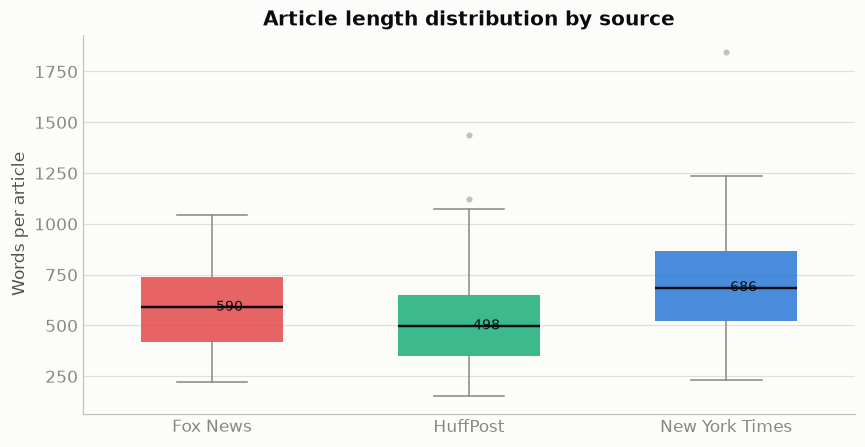

,mean,50%,min,max
source,,,,
fox,591.0,590.0,224.0,1042.0
hpo,534.0,498.0,151.0,1436.0
nyt,708.0,686.0,231.0,1847.0


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))
data = [articles.loc[articles.source == s, 'word_count'].dropna().values for s in SOURCE_ORDER]
bp = ax.boxplot(data, vert=True, widths=0.55, patch_artist=True,
                medianprops=dict(color=INK, linewidth=1.6),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='o', markersize=4, markerfacecolor=MUTED,
                                markeredgecolor='none', alpha=0.5))
for patch, s in zip(bp['boxes'], SOURCE_ORDER):
    patch.set_facecolor(SOURCE_COLORS[s]); patch.set_alpha(0.85); patch.set_edgecolor('none')
ax.set_xticklabels([SOURCE_LABEL[s] for s in SOURCE_ORDER])
ax.set_ylabel('Words per article')
ax.set_title('Article length distribution by source')
style(ax)
for i, s in enumerate(SOURCE_ORDER, 1):
    med = np.median(articles.loc[articles.source == s, 'word_count'].dropna())
    ax.text(i, med, f' {int(med)}', va='center', ha='left', color=INK, fontsize=9)
save(fig, 'fig2_article_length.png'); plt.show()

articles.groupby('source')['word_count'].describe()[['mean','50%','min','max']].round(0).loc[SOURCE_ORDER]

**Read:** the three outlets write at broadly similar lengths, so raw annotation counts aren't badly skewed by verbosity — but we still normalise by length in §4 to be safe.

## 3. Where is the bias? Annotations per source

The heart of BASIL. Each annotation is a human-marked span of biased language.
How many did annotators find in each outlet's coverage?

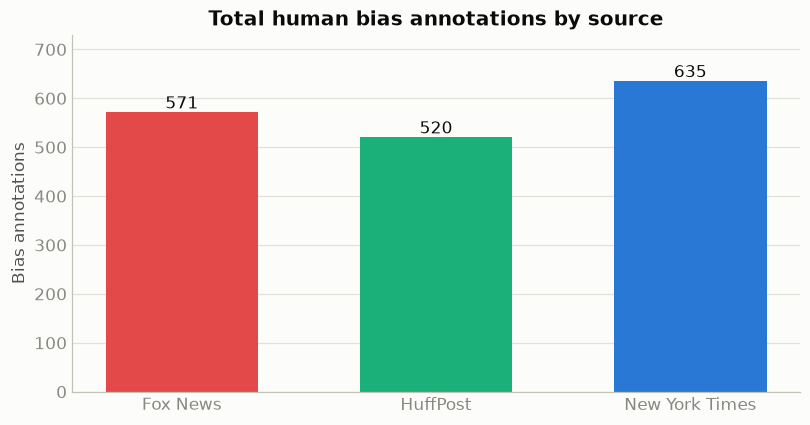

source
fox    571
hpo    520
nyt    635
Name: count, dtype: int64

In [5]:
counts = annotations['source'].value_counts().reindex(SOURCE_ORDER)
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar([SOURCE_LABEL[s] for s in SOURCE_ORDER], counts.values,
              color=[SOURCE_COLORS[s] for s in SOURCE_ORDER], width=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v}', ha='center', va='bottom', color=INK, fontsize=11)
ax.set_ylabel('Bias annotations'); ax.set_title('Total human bias annotations by source')
style(ax); ax.set_ylim(0, counts.max()*1.15)
save(fig, 'fig3_annotations_by_source.png'); plt.show()
counts

## 4. A fairer comparison: annotation *density*

Raw counts mix "how biased" with "how much was written." Annotations per
1,000 words controls for length and is the more honest cross-source signal.

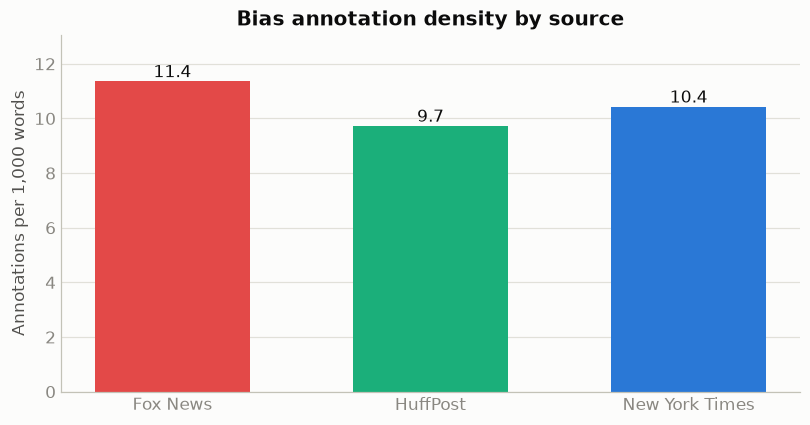

,annotations,total_words,per_1k_words
source,,,
fox,571,50246.0,11.36
hpo,520,53424.0,9.73
nyt,635,60856.0,10.43


In [6]:
words = articles.groupby('source')['word_count'].sum().reindex(SOURCE_ORDER)
ann = annotations['source'].value_counts().reindex(SOURCE_ORDER)
density = (ann / words * 1000)
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar([SOURCE_LABEL[s] for s in SOURCE_ORDER], density.values,
              color=[SOURCE_COLORS[s] for s in SOURCE_ORDER], width=0.6)
for b, v in zip(bars, density.values):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.1f}', ha='center', va='bottom', color=INK, fontsize=11)
ax.set_ylabel('Annotations per 1,000 words'); ax.set_title('Bias annotation density by source')
style(ax); ax.set_ylim(0, density.max()*1.15)
save(fig, 'fig4_annotation_density.png'); plt.show()
pd.DataFrame({'annotations': ann, 'total_words': words, 'per_1k_words': density.round(2)})

## 5. What *kind* of bias? Informational vs. lexical

BASIL distinguishes two bias types:
- **Informational (`inf`)** — bias from *what* is reported: added context,
  selective facts, who gets quoted.
- **Lexical (`lex`)** — bias from *word choice*: loaded or slanted phrasing.

NewsLens's framing metric is closest to *lexical* bias, while its omission
signal targets *informational* bias — so this split maps directly onto the
project's two core measures.

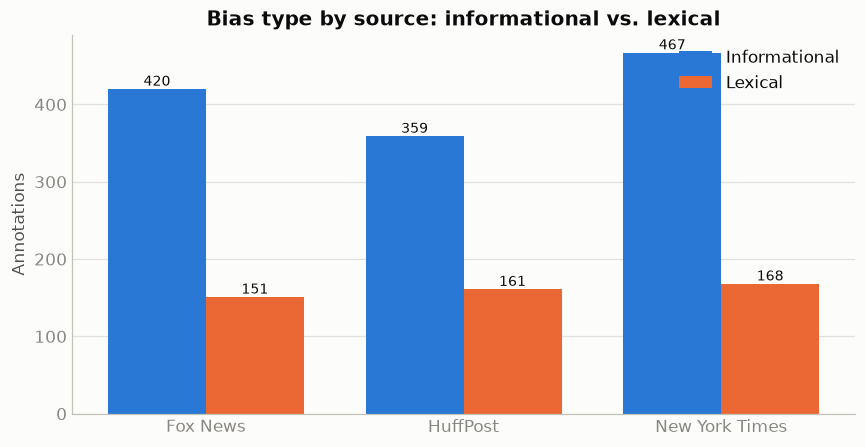

Overall: informational 1246 (72%), lexical 480 (28%)


bias,inf,lex
source,,
fox,420,151
hpo,359,161
nyt,467,168


In [7]:
ct = pd.crosstab(annotations['source'], annotations['bias']).reindex(SOURCE_ORDER)[['inf','lex']]
x = np.arange(len(SOURCE_ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.2))
b1 = ax.bar(x - w/2, ct['inf'], w, label='Informational', color=BLUE)
b2 = ax.bar(x + w/2, ct['lex'], w, label='Lexical', color=ORANGE)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{int(b.get_height())}',
                ha='center', va='bottom', color=INK, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([SOURCE_LABEL[s] for s in SOURCE_ORDER])
ax.set_ylabel('Annotations'); ax.set_title('Bias type by source: informational vs. lexical')
ax.legend(frameon=False, loc='upper right'); style(ax)
save(fig, 'fig5_bias_type.png'); plt.show()

overall = annotations['bias'].value_counts()
print(f"Overall: informational {overall.get('inf',0)} ({overall.get('inf',0)/len(annotations):.0%}), "
      f"lexical {overall.get('lex',0)} ({overall.get('lex',0)/len(annotations):.0%})")
ct

**Read:** informational bias dominates (~72%) across all three outlets. Bias in this corpus is mostly about *what gets said*, not just loaded wording — which is why NewsLens invests as much in omission/framing as in word-level classification.

## 6. Direction of bias: negative vs. positive

Each span is marked as leaning **negative** or **positive** toward its target.
We use the validated diverging pair (blue = positive, red = negative).

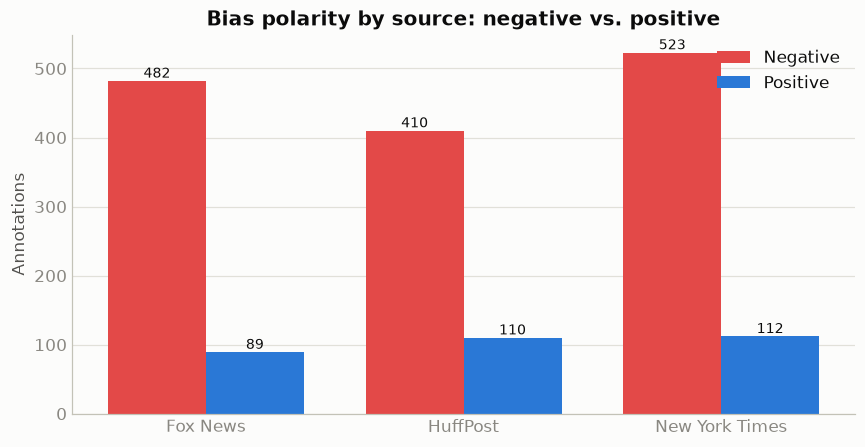

Overall: negative 1415 (82%), positive 311 (18%)


polarity,neg,pos
source,,
fox,482,89
hpo,410,110
nyt,523,112


In [8]:
ct = pd.crosstab(annotations['source'], annotations['polarity']).reindex(SOURCE_ORDER)[['neg','pos']]
x = np.arange(len(SOURCE_ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.2))
b1 = ax.bar(x - w/2, ct['neg'], w, label='Negative', color=RED)
b2 = ax.bar(x + w/2, ct['pos'], w, label='Positive', color=BLUE)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{int(b.get_height())}',
                ha='center', va='bottom', color=INK, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([SOURCE_LABEL[s] for s in SOURCE_ORDER])
ax.set_ylabel('Annotations'); ax.set_title('Bias polarity by source: negative vs. positive')
ax.legend(frameon=False, loc='upper right'); style(ax)
save(fig, 'fig6_polarity.png'); plt.show()

overall = annotations['polarity'].value_counts()
print(f"Overall: negative {overall.get('neg',0)} ({overall.get('neg',0)/len(annotations):.0%}), "
      f"positive {overall.get('pos',0)} ({overall.get('pos',0)/len(annotations):.0%})")
ct

**Read:** biased language in political news skews strongly **negative** (~82%) — a class imbalance any bias *classifier* trained on this data must reckon with (it's why NewsLens's Kaggle notebook selects models by F1, not accuracy).

## 7. Direct vs. indirect bias

`aim` records whether the bias points **directly** at a target, or **indirectly**
— framing something as pro/anti a side, or general slant.

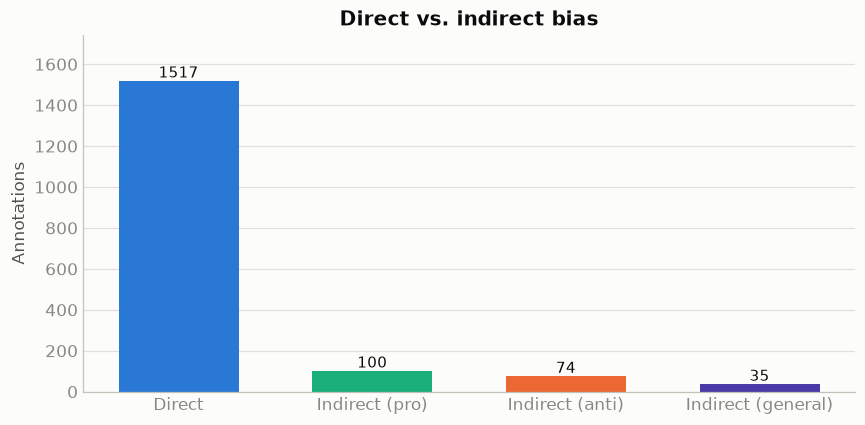

aim
dir            1517
ind_pro         100
ind_anti         74
ind_general      35
Name: count, dtype: int64

In [9]:
aim_order = ['dir', 'ind_pro', 'ind_anti', 'ind_general']
aim_label = {'dir':'Direct', 'ind_pro':'Indirect (pro)', 'ind_anti':'Indirect (anti)', 'ind_general':'Indirect (general)'}
aim_color = {'dir':BLUE, 'ind_pro':AQUA, 'ind_anti':ORANGE, 'ind_general':VIOLET}
counts = annotations['aim'].value_counts().reindex(aim_order).fillna(0)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([aim_label[a] for a in aim_order], counts.values,
              color=[aim_color[a] for a in aim_order], width=0.62)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v, f'{int(v)}', ha='center', va='bottom', color=INK, fontsize=10)
ax.set_ylabel('Annotations'); ax.set_title('Direct vs. indirect bias')
style(ax); ax.set_ylim(0, counts.max()*1.15)
save(fig, 'fig7_aim.png'); plt.show()
counts.astype(int)

**Read:** the large majority of annotated bias is **direct** (~88%) — aimed squarely at a named target, which is why entity-level analysis (NewsLens's NER + per-entity sentiment) captures most of the signal.

## 8. Bias inside quotes vs. the reporter's own voice

`quote` flags whether a biased span sits inside a quotation. Bias in the
outlet's *own* narration is editorially different from quoting a biased source.

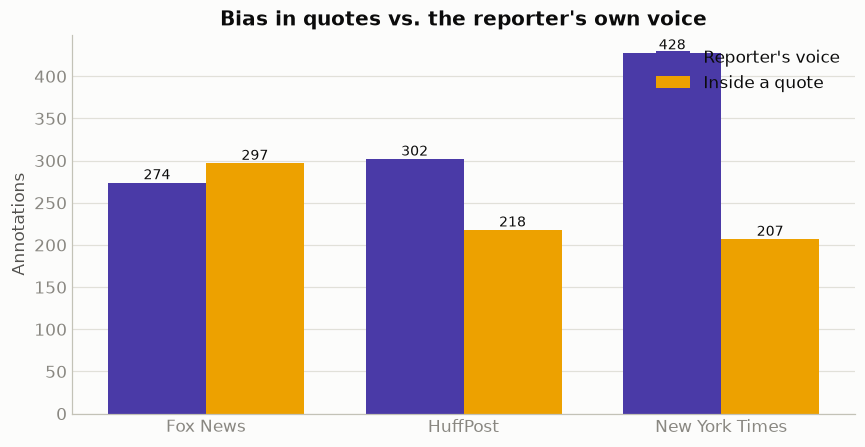

Overall: reporter's voice 1004 (58%), in quotes 722 (42%)


quote,no,yes
source,,
fox,274,297
hpo,302,218
nyt,428,207


In [10]:
ct = pd.crosstab(annotations['source'], annotations['quote']).reindex(SOURCE_ORDER)[['no','yes']]
x = np.arange(len(SOURCE_ORDER)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.2))
b1 = ax.bar(x - w/2, ct['no'], w, label="Reporter's voice", color=VIOLET)
b2 = ax.bar(x + w/2, ct['yes'], w, label='Inside a quote', color=YELLOW)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{int(b.get_height())}',
                ha='center', va='bottom', color=INK, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([SOURCE_LABEL[s] for s in SOURCE_ORDER])
ax.set_ylabel('Annotations'); ax.set_title("Bias in quotes vs. the reporter's own voice")
ax.legend(frameon=False, loc='upper right'); style(ax)
save(fig, 'fig8_quote.png'); plt.show()
overall = annotations['quote'].value_counts()
print(f"Overall: reporter's voice {overall.get('no',0)} ({overall.get('no',0)/len(annotations):.0%}), "
      f"in quotes {overall.get('yes',0)} ({overall.get('yes',0)/len(annotations):.0%})")
ct

## 9. Who gets targeted most?

The `target` field names the entity each biased span is about. The most-targeted
entities reveal what these stories are really contesting.

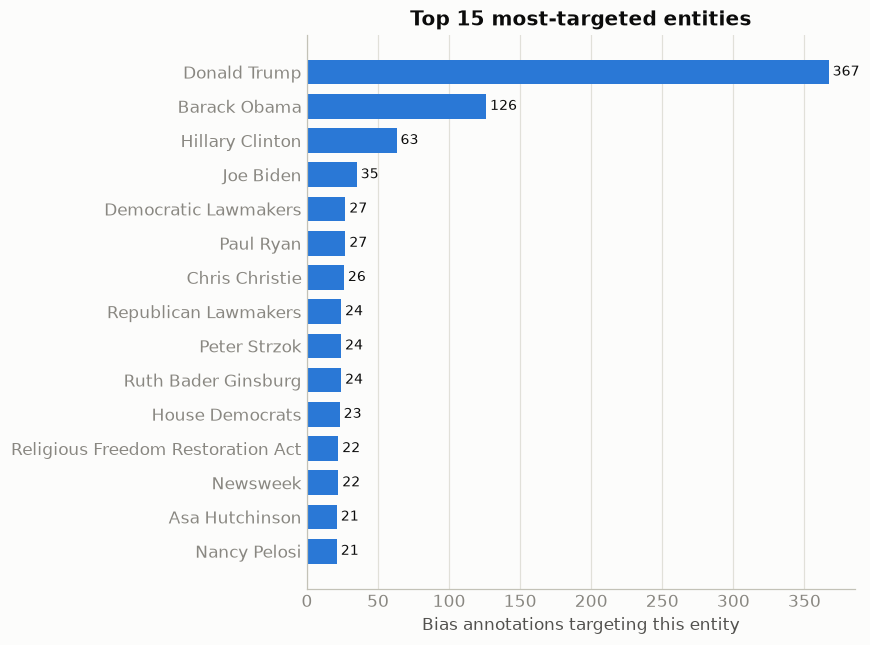

target
Donald Trump            367
Barack Obama            126
Hillary Clinton          63
Joe Biden                35
Democratic Lawmakers     27
Paul Ryan                27
Chris Christie           26
Republican Lawmakers     24
Peter Strzok             24
Ruth Bader Ginsburg      24
Name: count, dtype: int64

In [11]:
tgt = annotations['target'].dropna()
tgt = tgt[tgt.str.strip() != ''].str.replace('_', ' ').str.strip()
top = tgt.value_counts().head(15)[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top.index, top.values, color=BLUE, height=0.72)
for b, v in zip(bars, top.values):
    ax.text(v, b.get_y()+b.get_height()/2, f' {v}', va='center', ha='left', color=INK, fontsize=9)
ax.set_xlabel('Bias annotations targeting this entity')
ax.set_title('Top 15 most-targeted entities')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, color=GRID, linewidth=0.8); ax.set_axisbelow(True); ax.tick_params(length=0)
save(fig, 'fig9_top_targets.png'); plt.show()
top[::-1].head(10)

**Read:** targets are dominated by major U.S. political figures and institutions — confirming BASIL is a *political* news corpus, and that entity canonicalization (merging `Donald Trump` / `Trump`) is essential before any per-target counting is trustworthy.

## 10. Temporal coverage

When were these stories published? This bounds how "current" the curated corpus
is — and motivates NewsLens's live-ingestion extension for present-day news.

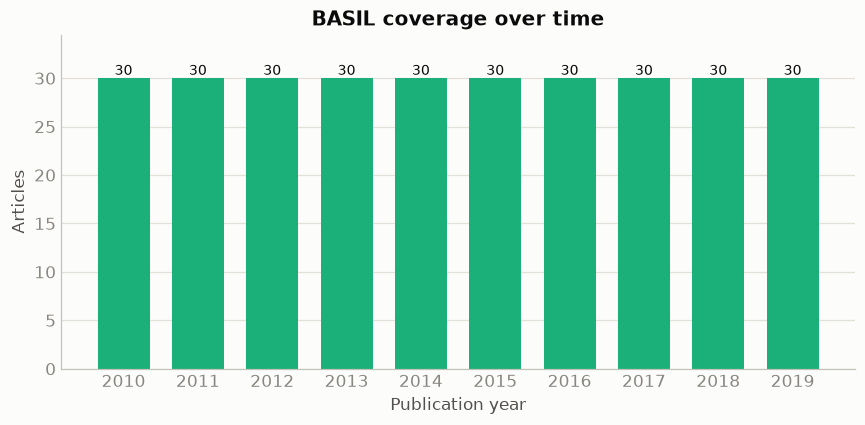

year
2010    30
2011    30
2012    30
2013    30
2014    30
2015    30
2016    30
2017    30
2018    30
2019    30
dtype: int64

In [12]:
by_year = articles.dropna(subset=['year']).groupby('year').size()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(by_year.index.astype(int).astype(str), by_year.values, color=AQUA, width=0.7)
for b, v in zip(bars, by_year.values):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v}', ha='center', va='bottom', color=INK, fontsize=9)
ax.set_ylabel('Articles'); ax.set_xlabel('Publication year')
ax.set_title('BASIL coverage over time')
style(ax); ax.set_ylim(0, by_year.max()*1.15)
save(fig, 'fig10_temporal.png'); plt.show()
by_year.astype(int)

## 11. What stories does BASIL cover? (sample)

A sample of the `main-event` labels, to make the corpus concrete.

In [13]:
sample = (articles.drop_duplicates('event')[['main_event','date']]
          .dropna().sort_values('date').reset_index(drop=True))
sample['date'] = sample['date'].dt.strftime('%Y-%m-%d')
sample.head(15)

,main_event,date
0,Glenn Beck speaks at CPAC,2010-02-20
1,Richard Blumenthal lies about serving in Vietn...,2010-05-18
2,White House Asked Bill Clinton to Urge Sestak ...,2010-05-28
3,Rep Etheridge apologizes for grabbing a young man,2010-06-14
4,Michael Steele Criticized for Afghanistan Comm...,2010-07-04
5,N.A.A.C.P. Challenges Tea Party on Racism,2010-07-14
6,Republican congressional candidates dispute pl...,2010-08-16
7,Republicans sign letter to stop legislature un...,2010-12-01
8,Larry Summers pressures congress to pass tax bill,2010-12-08
9,Michael Steele about to announce whether he'll...,2010-12-12


## 12. Key findings — summary

The cell below prints the headline findings and writes them to
`basil_analysis_summary.md` next to this notebook.

In [14]:
inf_pct = (annotations['bias']=='inf').mean()
neg_pct = (annotations['polarity']=='neg').mean()
dir_pct = (annotations['aim']=='dir').mean()
quote_pct = (annotations['quote']=='yes').mean()
dens = (annotations['source'].value_counts().reindex(SOURCE_ORDER)
        / articles.groupby('source')['word_count'].sum().reindex(SOURCE_ORDER) * 1000)

lines = [
    "# BASIL Dataset — EDA Summary",
    "",
    f"- **{articles['event'].nunique()} events**, **{len(articles)} articles**, "
    f"balanced triplets of Fox News / HuffPost / New York Times.",
    f"- **{len(annotations)} human bias annotations** "
    f"(mean {articles['n_annotations'].mean():.1f} per article).",
    f"- Bias is mostly **informational** ({inf_pct:.0%}) rather than lexical "
    f"({1-inf_pct:.0%}) — about *what* is reported, not only word choice.",
    f"- Biased language skews strongly **negative** ({neg_pct:.0%} vs "
    f"{1-neg_pct:.0%} positive) — a class imbalance for any bias classifier.",
    f"- Bias is overwhelmingly **direct** ({dir_pct:.0%}), aimed at a named target.",
    f"- **{quote_pct:.0%}** of biased spans sit inside quotations; the rest are "
    f"the reporter's own voice.",
    "- Annotation **density** per 1,000 words: "
    + ", ".join(f"{SOURCE_LABEL[s]} {dens[s]:.1f}" for s in SOURCE_ORDER) + ".",
    f"- Coverage spans **{articles['date'].min():%Y}–{articles['date'].max():%Y}**; "
    f"a handful of events use uppercase source names (normalised on load).",
    "",
    "**Why it matters for NewsLens:** BASIL's human spans are the ground truth "
    "the project validates its framing metric against; the dominance of "
    "informational + direct bias justifies the entity-, omission-, and "
    "framing-centred design, and the negative-class imbalance is why the bias "
    "classifier is selected by F1 rather than accuracy.",
]
report = "\n".join(lines)
open('basil_analysis_summary.md', 'w', encoding='utf-8').write(report)
print(report)

# BASIL Dataset — EDA Summary

- **100 events**, **300 articles**, balanced triplets of Fox News / HuffPost / New York Times.
- **1726 human bias annotations** (mean 5.8 per article).
- Bias is mostly **informational** (72%) rather than lexical (28%) — about *what* is reported, not only word choice.
- Biased language skews strongly **negative** (82% vs 18% positive) — a class imbalance for any bias classifier.
- Bias is overwhelmingly **direct** (88%), aimed at a named target.
- **42%** of biased spans sit inside quotations; the rest are the reporter's own voice.
- Annotation **density** per 1,000 words: Fox News 11.4, HuffPost 9.7, New York Times 10.4.
- Coverage spans **2010–2019**; a handful of events use uppercase source names (normalised on load).

**Why it matters for NewsLens:** BASIL's human spans are the ground truth the project validates its framing metric against; the dominance of informational + direct bias justifies the entity-, omission-, and framing-centred design, and t

---

### Deliverables produced by this notebook
- **Figures** (`figures/fig2…fig10*.png`) — ready to drop into slides or a report.
- **`basil_analysis_summary.md`** — the text summary above.

*Reproduce:* open in Jupyter and **Run All**, or from the repo root run
`jupyter nbconvert --to notebook --execute --inplace notebooks/basil_dataset_analysis.ipynb`.